# Modernized replacement for the old Tensor2Tensor Intro Colab

This version removes Tensor2Tensor and TensorFlow 1.x constructs such as:
- tf.contrib.eager
- tf.gfile
- tf.layers
- tf.train.AdamOptimizer
- tf.estimator.ModeKeys
- Tensor2Tensor problems/models/registry/trainer_lib

Modern replacements:
- TensorFlow / Keras for MNIST loading, CNN training, and evaluation
- Hugging Face Transformers for English -> German translation

Recommended Colab runtime: Python 3, GPU optional.

### Original Code, now deprecated, Copyright 2018 Google LLC.


In [2]:
# ============================================================
# 1. Install dependencies - Colab cell
# ============================================================
# In Colab, run this in its own cell:
# !pip install -q --upgrade "transformers" "sentencepiece"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 107.1 MB/s eta 0:00:00


In [3]:
import tensorflow as tf
import transformers
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
import os

print("TensorFlow:", tf.__version__)
print("Transformers:", transformers.__version__)
print("TF:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

# Check GPU
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Setup directories
data_dir = "./data"
model_dir = "./models"

os.makedirs(data_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)


TensorFlow: 2.20.0
Transformers: 5.9.0
TF: 2.20.0
Keras: 3.13.2
TensorFlow Version: 2.20.0
Keras Version: 3.13.2
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# =========================================
# Load MNIST Dataset
# =========================================

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

print("Pixel range:", x_train.min(), "to", x_train.max())
print("First label:", y_train[0])



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)
Pixel range: 0 to 255
First label: 5


Here is a breakdown of what happens behind the scenes and what those specific print outputs mean when you load the MNIST dataset in Google Colab.

---

### Step 1: Downloading the Dataset

```text
Downloading data from https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz...

```

* **What happens:** Keras checks if you already have the MNIST dataset saved locally in your Colab environment cache (usually in `~/.keras/datasets/`).
* **The action:** Because it is your first time running it in this session, Keras reaches out to Google Cloud Storage, downloads a compressed NumPy archive file (`mnist.npz`), and saves it to your environment. The file is relatively small (~11.5 MB), which is why the download completes in under a second.

---

### Step 2: Unpacking and Uncompressing the Data

```python
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

```

* **What happens:** Once downloaded, Keras automatically unpacks the `.npz` file and uses Python's **tuple unpacking** to distribute the data into four distinct NumPy arrays.
* **The split:** It automatically splits the dataset into a **Training set** (85.7% of the data) used to train your model, and a **Testing set** (14.3% of the data) kept aside to evaluate how well your model generalizes to unseen images.

---

### Step 3: Understanding the Data Shapes (The Dimensions)

```text
x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)

```

This output tells you the exact structural geometry of your datasets:

* **`x_train` and `x_test` (The Images):** * `(60000, 28, 28)` means you have **60,000 images** in the training set.
* Each individual image is a 2D grid of **28 pixels wide by 28 pixels high**.
* `x_test` has the exact same 28x28 spatial dimensions, but contains **10,000 images**.


* **`y_train` and `y_test` (The Labels):**
* `(60000,)` and `(10000,)` are **1D vectors** (flat arrays).
* Every single image has exactly one corresponding numerical label telling the computer what digit is written in the photo.



---

### Step 4: Inspecting the Pixel Values

```text
Pixel range: 0 to 255

```

* **What happens:** This reveals how the image data is encoded. MNIST consists of **grayscale** images.
* **The encoding:** Each pixel is represented by an 8-bit unsigned integer (`uint8`):
* **0** represents pure black.
* **255** represents pure white.
* Any number in between represents a shade of gray.



> *Note: Because neural networks typically perform better with small, normalized inputs, a common next step in your pipeline will be dividing these arrays by 255.0 to scale this range down to $[0, 1]$.*

---

### Step 5: Reading the Target Label

```text
First label: 5

```

* **What happens:** `y_train[0]` looks at the very first element in the training label array.
* **The interpretation:** The output `5` indicates that the very first 28x28 image matrix (`x_train[0]`) is a handwritten digit **5**. If you were to plot `x_train[0]` using a library like Matplotlib, you would see a visual representation of a five.

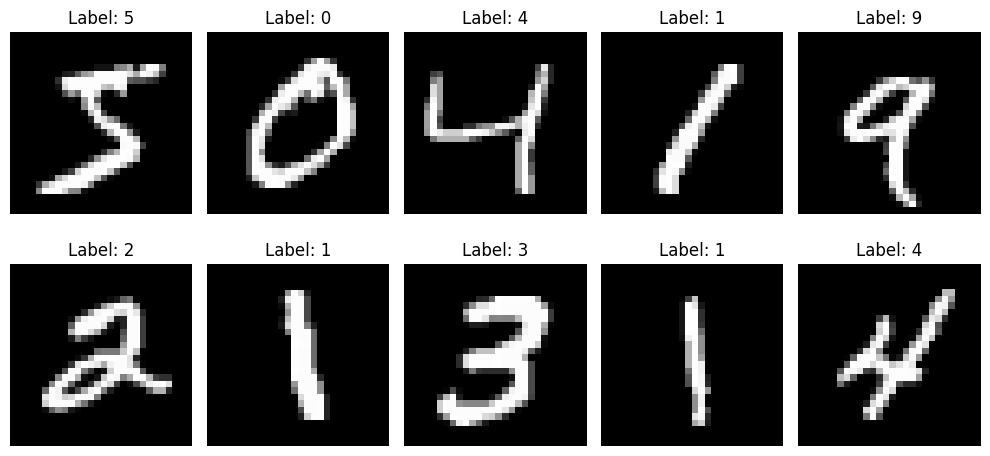

In [5]:

# =========================================
# Visualize Sample Digits
# =========================================

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


This snippet takes the raw pixel numbers we just looked at and uses Matplotlib to visually plot the first 10 images from the dataset into a clean $2 \times 5$ grid.

Here is exactly how each line works to construct that visualization:

---

### 1. Setting up the Canvas

```python
plt.figure(figsize=(10, 5))

```

* **What it does:** This initializes a blank figure window (your canvas).
* **The numbers:** `figsize=(10, 5)` defines the width and height of the total figure in inches. Making it wider than it is tall (10 inches wide, 5 inches high) perfectly accommodates a wide layout like 2 rows of 5 images.

---

### 2. The Loop (Iterating 10 Times)

```python
for i in range(10):

```

* **What it does:** This sets up a loop where the variable `i` will count from `0` up to `9`. Each loop iteration will handle exactly one image and place it onto the grid.

---

### 3. Carving out the Grid Slots

```python
    plt.subplot(2, 5, i + 1)

```

* **What it does:** This tells Matplotlib to treat the canvas as a grid of subplots.
* **The arguments:** * `2, 5`: Specifies a grid with **2 rows** and **5 columns** (10 slots total).
* `i + 1`: Specifies *which* slot to activate. Matplotlib grid slots are 1-indexed (counting from 1 to 10), but Python loops start at 0. So, when `i=0`, it activates slot 1; when `i=9`, it activates slot 10.



---

### 4. Drawing the Image

```python
    plt.imshow(x_train[i], cmap='gray')

```

* **What it does:** `imshow` stands for "image show." It takes the 28x28 matrix of numbers at index `i` (e.g., `x_train[0]`, `x_train[1]`) and renders it as a visual image.
* **`cmap='gray'`:** This is crucial. By default, Matplotlib will display grayscale data in a greenish-yellow color map (called 'viridis'). Passing `'gray'` forces it to render the numbers accurately: 0 as black, 255 as white, and the rest as shades of gray.

---

### 5. Adding the Target Label

```python
    plt.title(f"Label: {y_train[i]}")

```

* **What it does:** This uses a Python f-string to look up the actual target answer in the `y_train` array and prints it as a mini-title right above that specific image. This lets you visually confirm that the image looks like the number the computer thinks it is (e.g., seeing a drawn "5" with the title "Label: 5").

---

### 6. Cleaning Up the Borders

```python
    plt.axis('off')

```

* **What it does:** By default, Matplotlib treats images like graphs and draws X and Y axes with pixel coordinate ticks (0 to 28) around every image. This line turns those off, removing the borders and numbers so you only see the handwritten digit cleanly.

---

### 7. Polishing and Displaying

```python
plt.tight_layout()
plt.show()

```

* **`plt.tight_layout()`:** This is a formatting lifesaver. It automatically adjusts the spacing between the 10 subplots so that the titles and images don't overlap or crowd each other.
* **`plt.show()`:** This tells Matplotlib that you are finished building the plot and instructs Colab to actually render and display the final image grid on your screen.

In [6]:
# =========================================
# Normalize and Reshape Data
# =========================================

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("New x_train shape:", x_train.shape)
print("New x_test shape:", x_test.shape)

print("New pixel range:")
print("Min:", x_train.min())
print("Max:", x_train.max())

New x_train shape: (60000, 28, 28, 1)
New x_test shape: (10000, 28, 28, 1)
New pixel range:
Min: 0.0
Max: 1.0


This section of the code handles two critical preprocessing steps required before feeding image data into a deep learning model: **Feature Scaling (Normalization)** and **Tensor Reshaping**.

Here is why these steps are necessary and exactly what the code is doing.

---

### Part 1: Normalizing the Pixel Values

```python
x_train = x_train.astype("float32") / 255.0

```

#### What are we normalizing?

We are converting the raw pixel intensities of every single image from their original integer scale into a standard floating-point scale.

#### Why are we dividing by 255.0?

As we discovered earlier, 8-bit grayscale pixels range from **0** (black) to **255** (white). By dividing every pixel value by `255.0`, we scale the data down so that it fits precisely into a range between **0.0 and 1.0**.

Neural networks do not handle large integer inputs (like 255) very well due to the underlying mathematics of how they learn:

* **Stable Gradients:** Neural networks use weights and activation functions (like Sigmoid or ReLU) to process data. If input values are large (e.g., 255), the math can cause gradients to "explode" or "saturate," severely slowing down or completely stalling the learning process.
* **Uniformity:** Keeping inputs bounded between 0 and 1 ensures numerical stability, making it much easier and faster for the optimization algorithms (like Gradient Descent) to find the ideal weights.
* **Why `.astype("float32")`?** Originally, the pixels are stored as integers (`uint8`). Dividing them requires decimal points. We cast them to `float32` (32-bit floating-point numbers) because deep learning frameworks like TensorFlow and Keras are heavily optimized to compute math on 32-bit floats.

---

### Part 2: Adding the Channel Dimension (Reshaping)

```python
x_train = np.expand_dims(x_train, -1)

```

#### Why are we doing this?

This step fixes a structural requirement for Convolutional Neural Networks (CNNs).

* Your original `x_train` shape was `(60000, 28, 28)`. It represents `(batch_size, height, width)`.
* Standard deep learning image layers *demand* a 4D tensor structure: **`(batch_size, height, width, channels)`**.

Even though these are grayscale images with only one color channel, the framework still expects that fourth dimension to be explicitly stated. Color images (RGB) would have `3` channels. Grayscale has `1`.

#### How `np.expand_dims(..., -1)` works:

The `-1` tells NumPy to add a new, empty dimension at the *very end* (the last axis) of the array's shape.

---

### Step 3: Checking the Output

```text
New x_train shape: (60000, 28, 28, 1)
New x_test shape: (10000, 28, 28, 1)

New pixel range:
Min: 0.0
Max: 1.0

```

The print statements confirm that your transformation was successful:

1. **The Shape:** The data has successfully transformed from a 3D matrix into a 4D tensor with a trailing `1`, making it perfectly formatted for a Keras `Conv2D` layer.
2. **The Range:** The pixel range has been squeezed down from `0 to 255` into a highly efficient math-friendly range of `0.0 to 1.0`.

Our data is now fully prepped and ready for a neural network!

In [8]:
# =========================================
# Build a Simple CNN Model - Keras 3 Style
# =========================================

model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

This step is where we actually build the brain of our AI. You are using `keras.Sequential`, which means the model is a linear stack where the data enters at the top and flows sequentially down through each layer until it spits out an answer at the bottom.

Here is exactly what each layer is doing as the image travels through this pipeline:

---

### 1. The Entrance

```python
keras.Input(shape=(28, 28, 1)),

```

* **What it does:** This defines the "doorway" of your model. It doesn't change the data; it just tells Keras to expect an incoming 4D tensor where each individual image has a shape of `(28, 28, 1)`.
* *Note: This explicit `keras.Input` line is a signature feature of **Keras 3**, ensuring the model immediately knows its structure without waiting for data to pass through it.*

---

### 2. The Feature Extractors (The "Vision" Block)

This block is repeated twice to extract complex patterns out of the pixels (like edges, loops, and corners).

```python
keras.layers.Conv2D(32, (3, 3), activation='relu'),
keras.layers.MaxPooling2D((2, 2)),

```

* **`Conv2D(32, (3, 3))`:** This is a Convolutional layer. It creates **32 small moving filters** (each $3 \times 3$ pixels in size) that slide across the image. They look for specific features like vertical lines, horizontal lines, or curves.
* **`activation='relu'`:** The Rectified Linear Unit ($f(x) = \max(0, x)$). It converts any negative number coming out of the math into a `0`. This injects non-linearity into our model, allowing it to learn complex, non-linear shapes instead of just straight lines.
* **`MaxPooling2D((2, 2))`:** This is downsampling. It looks at the image in $2 \times 2$ pixel blocks and keeps *only* the maximum value, throwing away the rest. This cuts the spatial size of the image exactly in half (e.g., from $26 \times 26$ down to $13 \times 13$), reducing computational load and helping the model become invariant to small shifts in where the number is drawn.

The next two lines do the exact same thing, but scale up to **64 filters** to catch more intricate combinations of features (like the loop of a "6" or the intersection of a "4").

---

### 3. The Bridge

```python
keras.layers.Flatten(),

```

* **What it does:** Convolutional layers deal with 2D spatial matrices, but standard classification layers require a flat 1D vector. `Flatten()` takes the final high-level 2D feature maps and unrolls them into a long, single row of numbers. (For example, if the data is $5 \times 5 \times 64$, it flattens it into a single vector of $1,600$ numbers).

---

### 4. The Reasoning & Classification Block (The "Brain")

```python
keras.layers.Dense(128, activation='relu'),

```

* **What it does:** This is a fully-connected (Dense) layer with 128 neurons. Now that the spatial information is flattened, this layer looks at all the extracted features simultaneously and starts pieceing them together to reason what the number actually is.

```python
keras.layers.Dropout(0.5),

```

* **What it does:** This is a powerful regularization technique to prevent **overfitting** (cheating/memorizing the training images). During training, it randomly switches off 50% (`0.5`) of the neurons in this layer on every single step. This forces the remaining neurons to step up and learn independently, ensuring the network doesn't become overly reliant on specific, brittle pathways.

```python
keras.layers.Dense(10, activation='softmax')

```

* **`Dense(10)`:** The final layer has exactly **10 neurons**, because our target has 10 possible categories (the digits 0 through 9).
* **`activation='softmax'`:** This translates the final raw scores of those 10 neurons into a **probability distribution** that adds up to exactly 1.0 (or 100%). For instance, the output might look like a list of decimals where index `5` has a value of `0.98`, meaning the model is 98% confident the image is a 5.

---

### 5. Inspecting the Blueprint

```python
model.summary()

```

* **What it does:** This prints out a structured table showing every layer, the shape of the data as it changes after passing through that layer, and the total number of trainable weights (parameters) the computer has to optimize. It’s your map to verify everything was built exactly as intended.

In [9]:
# =========================================
# Compile the Model
# =========================================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Compiling the model is the step where you configure its learning strategy. Up to this point, you have only built the architectural blueprint (the neurons and layers). Compiling assigns the math formulas that dictate **how** the model learns from its mistakes, **how** it measures those mistakes, and **how** you will track its progress.

Here is the breakdown of the three parameters you defined, along with alternative options for the optimizer.

---

### 1. The Metrics (`metrics=['accuracy']`)

This is the easiest parameter to understand. It is simply the report card you want to see during training. By choosing `'accuracy'`, Keras will print out the percentage of images the model guessed correctly after every training epoch (e.g., `0.945` means 94.5% accuracy).

---

### 2. The Loss Function (`loss='sparse_categorical_crossentropy'`)

The loss function is the mathematical formula used to calculate exactly **how wrong** the model's guess was. Think of it as a penalty score: the closer the model's guess is to the truth, the lower this number is.

* **Why this one?** You used `'sparse_categorical_crossentropy'` because your dataset uses **integer labels** (e.g., the label is literally the number `5`, `3`, or `0`).
* **The Alternative:** If you had preprocessed your labels using "One-Hot Encoding" (where the number 5 is represented as a vector like `[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]`), you would change this parameter to standard `'categorical_crossentropy'`.

---

### 3. The Optimizer (`optimizer='adam'`)

The optimizer is the algorithm that actually updates the weights of your neural network based on the loss calculation. If the loss function tells you *how bad* the model did, the optimizer is the mechanic that reaches into the engine to tweak the knobs so it does better next time.

You chose **`'adam'`** (Adaptive Moment Estimation), which is the industry gold standard for most deep learning problems because it automatically adjusts the learning rate as it trains—starting fast and slowing down as it gets closer to a perfect solution.

#### Other Popular Optimizer Options:

If you wanted to swap out `'adam'`, here are the most common alternatives you could type into that string:

| Optimizer Name | Keras String | How it works / When to use it |
| --- | --- | --- |
| **Stochastic Gradient Descent** | `'sgd'` | The classic, old-school method. It updates weights in small, steady steps. While reliable, standard SGD can be very slow. It is often paired with a momentum parameter (`keras.optimizers.SGD(momentum=0.9)`) to help it accelerate through flat areas of the math landscape. |
| **Root Mean Squared Propagation** | `'rmsprop'` | This was developed to fix SGD's tendency to get stuck or oscillate wildly. It adjusts the learning rate for each weight individually. It is highly favored and often outperforms Adam when working with **Recurrent Neural Networks (RNNs)** or text/sequence data. |
| **AdamW** | `'adamw'` | A modern variation of Adam that fixes a mathematical bug in how Adam handles weight decay (regularization). If your model is large and prone to overfitting, switching to `'adamw'` often yields cleaner generalization on test data. |
| **Adagrad** | `'adagrad'` | An adaptive algorithm that drops the learning rate sharply for features that appear frequently, and keeps it high for rare features. It's excellent for sparse data (like text processing with massive vocabularies), but generally poor for computer vision tasks like MNIST because the learning rate decays too quickly and freezes training early. |

For a simple CNN running on the MNIST dataset, **`'adam'`** or **`'rmsprop'`** will easily blast you past 98% accuracy in just a few rounds of training!

### Where do we specify the Learning Rate and Epochs
You specify the **Learning Rate** and the **Epochs** in two different places because they handle different parts of the process: one belongs to the *setup* (the optimizer), and the other belongs to the *execution* (the actual training loop).

Here is exactly where they go:

---

### 1. Where to Specify the Learning Rate (In `model.compile`)

Right now, you are passing the string `'adam'`, which uses Keras's default learning rate (usually `0.001`).

If you want to customize it, you swap out that simple text string for the actual Keras optimizer object. This gives you direct control over its internal knobs, including the learning rate (`lr` or `learning_rate`):

```python
# Import the optimizers module
from keras import optimizers

model.compile(
    # Instead of 'adam', we instantiate it manually:
    optimizer=optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

```

* **Why tweak it?** If your model is learning too slowly, you might bump it up. If your model's accuracy is jumping around erratically or the loss is exploding, it means the learning rate is too high and it's overshooting the solution—so you turn it down.

---

### 2. Where to Specify the Epochs (In `model.fit`)

Epochs dictate how many times the model gets to look at the entire training dataset from start to finish. This is passed as an argument when you actually run the training command, which is `model.fit()`:

```python
# This is the line where the actual training happens
history = model.fit(
    x_train,
    y_train,
    epochs=10,           # <-- Specify your epochs here!
    batch_size=64,       # Optional: How many images to look at before updating weights
    validation_split=0.1 # Optional: Holds back 10% of training data to check progress
)

```

### To put it simply:

* You set the **learning rate** when you choose your *strategy* (`model.compile`). It controls how big of a step the model takes when adjusting its weights.
* You set the **epochs** when you tell the model to *start practicing* (`model.fit`). It controls how many rounds of practice it gets.

In [10]:
# =========================================
# Train the Model
# =========================================

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9081 - loss: 0.3032 - val_accuracy: 0.9822 - val_loss: 0.0639
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9709 - loss: 0.0973 - val_accuracy: 0.9890 - val_loss: 0.0420
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9794 - loss: 0.0688 - val_accuracy: 0.9885 - val_loss: 0.0395
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9825 - loss: 0.0583 - val_accuracy: 0.9905 - val_loss: 0.0352
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9852 - loss: 0.0496 - val_accuracy: 0.9910 - val_loss: 0.0326


This is the exact moment where the magic happens! Running `model.fit()` kicks off the actual training process. The computer stops looking at structural blueprints and starts actively studying the images, making mistakes, and updating its internal weights to learn how to read handwritten numbers.

Here is exactly what each parameter in this specific configuration means and how it controls the training engine:

---

### 1. The Raw Data (`x_train, y_train`)

These are your inputs and the corresponding answers. You are passing the 60,000 normalized images (`x_train`) and their correct numeric labels (`y_train`). The network will look at the images to make a guess, and then immediately look at the labels to see if it was right or wrong.

---

### 2. The Training Rounds (`epochs=5`)

An **epoch** is one full pass through the entire training dataset.

* By setting `epochs=5`, you are telling the network: *"You are going to study this entire stack of images 5 times from start to finish."*
* In early epochs, the accuracy will start low because the weights are completely random. By epoch 4 or 5, you will see the accuracy climb significantly as the network refines its internal filters.

---

### 3. The Pacing (`batch_size=128`)

The network does not look at all 60,000 images simultaneously, nor does it look at them one by one. Instead, it breaks the data into chunks.

* **What happens:** The model looks at a **batch of 128 images**, calculates their average error (loss), and uses the optimizer to update its weights exactly once. Then, it moves on to the next 128 images.
* **Why 128?** Looking at images one by one is too slow and errant; looking at all 60,000 at once takes too much computer memory. A batch size of 128 is a "Sweet Spot"—it fits perfectly into modern GPU memory processing pipelines, leading to incredibly fast calculations.

---

### 4. The Midterm Exam (`validation_split=0.1`)

This is a critical best-practice in machine learning.

* **The Math:** You are telling Keras to automatically peel away **10% of your training data** (6,000 images out of the 60,000) and hide them from the model. The model will only train its weights on the remaining 54,000 images.
* **The Purpose:** At the end of every single epoch, the model stops training and runs a test on those hidden 6,000 validation images.

This gives you two distinct output metrics on your screen during training:

1. **`accuracy` (Training Accuracy):** How well the model is performing on the images it is actively studying.
2. **`val_accuracy` (Validation Accuracy):** How well the model performs on images it has *never seen before*. If your training accuracy is 99% but your validation accuracy is only 80%, you instantly know your model is overfiting (memorizing the training set instead of learning actual patterns).

---

### 5. Catching the Output (`history = ...`)

By assigning this whole process to a variable called `history`, Keras automatically records a complete diary of the training process. Inside this variable, it saves a Python dictionary containing lists of the loss, accuracy, validation loss, and validation accuracy for every single epoch.

Later on, you can pass this `history` variable to a plotting library to instantly draw a beautiful line graph showing how your model's intelligence grew over those 5 rounds!

In [11]:
# =========================================
# Evaluate on Test Data
# =========================================

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9909 - loss: 0.0284
Test Loss: 0.028351299464702606
Test Accuracy: 0.9908999800682068


This step is the **"Final Exam"** for your neural network.

Up until this point, the model has been practicing and adjusting its weights based on the training data, and we used the validation split as a series of practice quizzes. However, to truly know if our AI has learned how to read handwritten numbers—or if it just memorized the training patterns—we must test it on entirely fresh data.

Here is what happens during `model.evaluate()`:

---

### 1. The Separation of Church and State

```python
test_loss, test_accuracy = model.evaluate(x_test, y_test)

```

* **What it does:** This command feeds the **10,000 completely unseen images** (`x_test`) and their corresponding real answers (`y_test`) into the trained model.
* **The Rules:** Unlike `model.fit()`, **the model is frozen here**. It does not adjust its weights, it doesn't use the optimizer, and it doesn't drop out neurons. It simply processes the 10,000 images, makes its absolute best guesses, and compares them to `y_test`.
* **Tuple Unpacking:** The function calculates the overall results and unpacks them into two distinct variables: `test_loss` and `test_accuracy`.

---

### 2. Reading the Final Scorecard

```python
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

```

#### Test Loss

This is the average categorical crossentropy penalty score across all 10,000 test images. While the exact number is hard for humans to intuitively interpret, you want this value to be as close to `0.0` as possible. More importantly, you want this number to be roughly similar to the final validation loss from your training loop.

#### Test Accuracy

This is the ultimate metric of success. If this prints out as `0.985`, it means your CNN successfully identified the correct digit on **98.5% of images it has never encountered before in its lifetime** (9,850 out of 10,000).

---

### The Diagnostics: How to Read the Relationship

When you look at these printed numbers alongside your final training metrics, you can instantly diagnose the health of your model:

* **Good Generalization (The Goal):** Your Training Accuracy is $\sim 99\%$ and your Test Accuracy is $\sim 98.5\%$. The gap is tiny. This means your filters (the convolutional layers looking for loops and edges) successfully learned universal concepts of what numbers look like.
* **Overfitting (The Trap):** Your Training Accuracy is $99.5\%$ but your Test Accuracy drops down to $91\%$. This tells you the model became *too* specialized. It memorized the specific quirks, handwriting styles, or pixel noise of the training set, leaving it unable to adapt to new handwriting styles in the test set. (If this happens, you usually need to increase your `Dropout` rate or add more data variance!)

Predicted Label: 7
True Label: 7


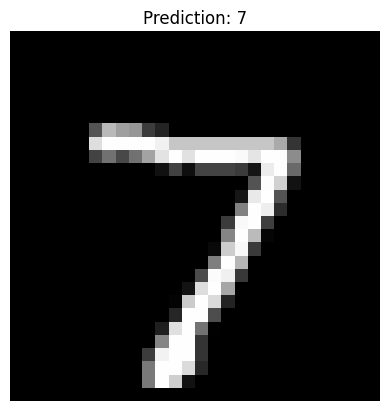

In [12]:
# =========================================
# Predict a Sample Digit
# =========================================

sample_index = 0

sample_image = x_test[sample_index]

prediction = model.predict(
    np.expand_dims(sample_image, axis=0),
    verbose=0
)

predicted_label = np.argmax(prediction)

print("Predicted Label:", predicted_label)
print("True Label:", y_test[sample_index])

plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Prediction: {predicted_label}")
plt.axis('off')
plt.show()

This final step moves away from looking at mass statistics (like overall accuracy) and demonstrates how to use your fully trained model in production to predict a single, specific image. It's the practical application of your AI.

Here is exactly how this sample prediction pipeline works line by line:

---

### 1. Slicing out a Single Sample

```python
sample_index = 0
sample_image = x_test[sample_index]

```

* **What it does:** It pulls out the very first image (index `0`) from your test dataset. This is a clean $28 \times 28 \times 1$ image array that the model has never seen during its training phase.

---

### 2. The Shape Trick (Adding the Batch Dimension)

```python
prediction = model.predict(np.expand_dims(sample_image, axis=0), verbose=0)

```

* **`np.expand_dims(sample_image, axis=0)`:** Keras models are designed to process data in **batches**, never as standalone items. Even if you want a prediction for just one image, the model strictly expects a 4D tensor input: `(batch_size, height, width, channels)`.
* By inserting a new axis at position `0`, you instantly transform the image's shape from `(28, 28, 1)` into `(1, 28, 28, 1)`. You are essentially tricking the model into thinking: *"Here is a batch of data that happens to contain exactly 1 image."*


* **`verbose=0`:** This simply turns off Keras’s default animated loading progress bar, keeping your Colab console completely clean when the prediction runs.

---

### 3. Decoding the Raw Prediction Array

```python
predicted_label = np.argmax(prediction)

```

* **What `model.predict()` actually outputs:** Because the last layer of your model uses a `softmax` activation with 10 neurons, `prediction` is not a single number. It is an array of **10 probabilities** representing how confident the model is for each digit from 0 to 9. It looks something like this:

$$[0.0001, \, 0.0000, \, 0.0003, \, 0.0000, \, 0.0000, \, 0.0002, \, 0.0000, \, \mathbf{0.9992}, \, 0.0001, \, 0.0001]$$


* **What `np.argmax()` does:** It scans that list of 10 numbers, finds the **maximum value** (in this case, `0.9992`), and returns its **index position**. Since `0.9992` sits at index position `7`, `np.argmax` outputs `7`. That is your model's official guess.

---

### 4. Cross-Checking the Answer

```python
print("Predicted Label:", predicted_label)
print("True Label:", y_test[sample_index])

```

* **What it does:** This prints the AI's guess side-by-side with the ground truth answer recorded in `y_test[0]`. This lets you immediately verify if the network's prediction matches reality. For the standard MNIST dataset, the first test image at index `0` is famously a handwritten **7**.

---

### 5. Visually Displaying the Result

```python
plt.imshow(sample_image.squeeze(), cmap='gray')

```

* **`sample_image.squeeze()`:** Matplotlib’s `imshow` function hates trailing dimensions. It cannot naturally plot a 3D shape like `(28, 28, 1)`. The `.squeeze()` function strips away any dimensions that have a size of 1, instantly flattening the shape back down to a clean 2D matrix of `(28, 28)` so Matplotlib can render it cleanly in grayscale.
* **The final block:** Just like we saw in the earlier visualization step, this adds the dynamic title showing the model's prediction, hides the graph grid axes (`axis('off')`), and pops the image onto your screen.

You get to see the actual handwritten digit and visually confirm that your custom neural network successfully recognized it!

In [15]:
print(dir(keras.datasets))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'boston_housing', 'california_housing', 'cifar10', 'cifar100', 'fashion_mnist', 'imdb', 'mnist', 'reuters']


In [16]:
# =========================================
# Modern English-to-German Translation Setup
# =========================================

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-en-de"

tokenizer = AutoTokenizer.from_pretrained(model_name)
translation_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Loaded:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Loaded: Helsinki-NLP/opus-mt-en-de


In [17]:
# =========================================
# Encode / Decode Helpers - Modern Version
# =========================================

def encode(input_str):
    """
    Convert input text into token IDs ready for the translation model.
    """
    return tokenizer(
        input_str,
        return_tensors="pt",
        padding=True,
        truncation=True
    )

def decode(token_ids):
    """
    Convert generated token IDs back into readable text.
    """
    return tokenizer.decode(
        token_ids[0],
        skip_special_tokens=True
    )

In [18]:
# =========================================
# Translate English to German
# =========================================

def translate(input_text):
    encoded = encode(input_text)

    generated_tokens = translation_model.generate(
        **encoded,
        max_length=80,
        num_beams=4
    )

    return decode(generated_tokens)

input_text = "The animal didn't cross the street because it was too tired."

output_text = translate(input_text)

print("Input:", input_text)
print("Output:", output_text)

Input: The animal didn't cross the street because it was too tired.
Output: Das Tier ist nicht über die Straße gegangen, weil es zu müde war.


In [19]:
# =========================================
# Generate Translation with Attention Outputs
# =========================================

input_text = "The animal didn't cross the street because it was too tired."

encoded = tokenizer(
    input_text,
    return_tensors="pt",
    padding=True,
    truncation=True
)

generated = translation_model.generate(
    **encoded,
    max_length=80,
    num_beams=4,
    return_dict_in_generate=True,
    output_attentions=True
)

generated_ids = generated.sequences
output_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

print("Input:", input_text)
print("Output:", output_text)

[transformers] `sdpa` attention does not support `output_attentions=True`. Please set your attention to `eager` if you want any of these features.


Input: The animal didn't cross the street because it was too tired.
Output: Das Tier ist nicht über die Straße gegangen, weil es zu müde war.


In [22]:
# =========================================
# Reload Translation Model with Attention Enabled
# =========================================

translation_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    attn_implementation="eager"
)

translation_model.config.output_attentions = True

print("Reloaded model with attention support.")

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Reloaded model with attention support.


In [23]:
input_text = "The animal didn't cross the street because it was too tired."

encoded = tokenizer(
    input_text,
    return_tensors="pt",
    padding=True,
    truncation=True
)

generated = translation_model.generate(
    **encoded,
    max_length=80,
    num_beams=4,
    return_dict_in_generate=True,
    output_attentions=True
)

generated_ids = generated.sequences
output_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

input_tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
output_tokens = tokenizer.convert_ids_to_tokens(generated_ids[0])

print("Input:", input_text)
print("Output:", output_text)
print("Input tokens:", input_tokens)
print("Output tokens:", output_tokens)

Input: The animal didn't cross the street because it was too tired.
Output: Das Tier ist nicht über die Straße gegangen, weil es zu müde war.
Input tokens: ['▁The', '▁animal', '▁didn', "'", 't', '▁cross', '▁the', '▁street', '▁because', '▁it', '▁was', '▁too', '▁tired', '.', '</s>']
Output tokens: ['<pad>', '▁Das', '▁Tier', '▁ist', '▁nicht', '▁über', '▁die', '▁Straße', '▁gegangen', ',', '▁weil', '▁es', '▁zu', '▁müde', '▁war', '.', '</s>']


In [24]:
# =========================================
# Visualize Encoder-Decoder Cross-Attention
# =========================================

# Run model again using the generated output as decoder input
attention_outputs = translation_model(
    **encoded,
    decoder_input_ids=generated_ids,
    output_attentions=True,
    return_dict=True
)

# Cross-attention: one tensor per decoder layer
cross_attentions = attention_outputs.cross_attentions

print("Number of decoder layers:", len(cross_attentions))
print("Shape of one attention tensor:", cross_attentions[-1].shape)

Number of decoder layers: 6
Shape of one attention tensor: torch.Size([1, 8, 17, 15])


# Translate from English to German with a pre-trained model

## Display Attention

In [25]:
# =========================================
# Load Attention-Friendly Translation Model
# =========================================

model_name = "google-t5/t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)

translation_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    attn_implementation="eager"
)

translation_model.config.output_attentions = True

print("Loaded:", model_name)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded: google-t5/t5-small


In [26]:
# =========================================
# Translate with Attention Outputs
# =========================================

input_text = "translate English to German: The animal didn't cross the street because it was too tired."

encoded = tokenizer(
    input_text,
    return_tensors="pt"
)

generated = translation_model.generate(
    **encoded,
    max_length=80,
    return_dict_in_generate=True,
    output_attentions=True
)

generated_ids = generated.sequences
output_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

input_tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
output_tokens = tokenizer.convert_ids_to_tokens(generated_ids[0])

print("Output:", output_text)

Output: Das Tier hat die Straße nicht überquert, weil es zu müde war.


Decoder layers: 6
One tensor shape: torch.Size([1, 8, 26, 20])


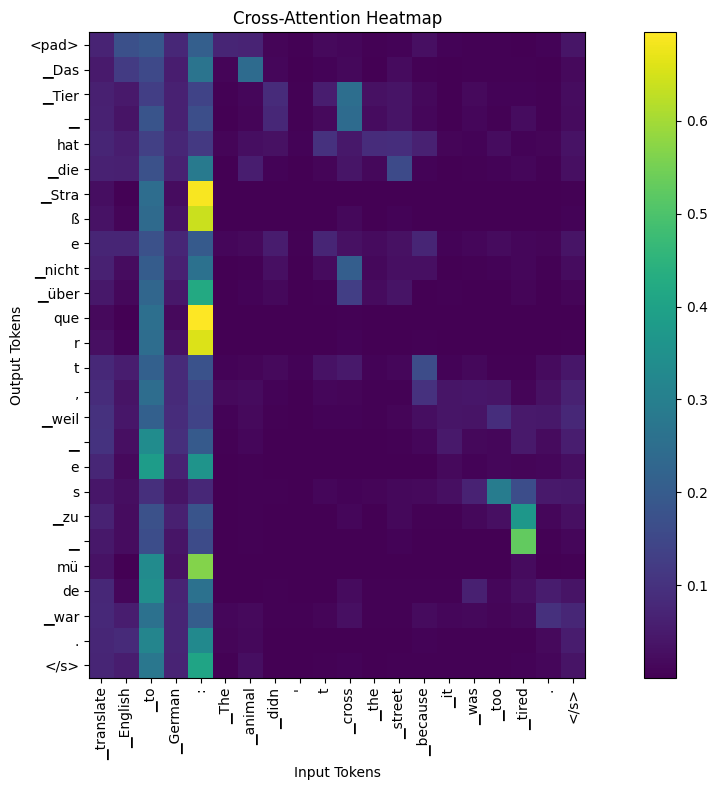

In [27]:
# =========================================
# Attention Heatmap
# =========================================

attention_outputs = translation_model(
    **encoded,
    decoder_input_ids=generated_ids,
    output_attentions=True,
    return_dict=True
)

cross_attentions = attention_outputs.cross_attentions

print("Decoder layers:", len(cross_attentions))
print("One tensor shape:", cross_attentions[-1].shape)

attention_matrix = cross_attentions[-1][0].mean(axis=0)
attention_matrix = attention_matrix.detach().cpu().numpy()

plt.figure(figsize=(12, 8))
plt.imshow(attention_matrix)

plt.xticks(np.arange(len(input_tokens)), input_tokens, rotation=90)
plt.yticks(np.arange(len(output_tokens)), output_tokens)

plt.xlabel("Input Tokens")
plt.ylabel("Output Tokens")
plt.title("Cross-Attention Heatmap")

plt.colorbar()
plt.tight_layout()
plt.show()